In [1]:
# 준비: 독립 GGMM·분할 선택·평가 함수 정의. 이 셀에서는 적합하지 않습니다.
"""Independent GGMM estimator with BIC-based component-count selection.

No CDF objective, DKW selection, shape penalty, b upper bound, random
initialization, held-out sample, or fitted GMM input. This is numerical local
maximum likelihood, not a variational Bayesian GGMM or guaranteed global MLE.
"""
from dataclasses import dataclass, asdict
from time import perf_counter
from typing import cast
import numpy as np
from numpy.typing import ArrayLike
from scipy.optimize import minimize, brentq
from scipy.special import gammaln, digamma, logsumexp
from scipy.stats import gennorm


@dataclass(init=False)
class Mixture:
    weights: np.ndarray
    means: np.ndarray
    scales: np.ndarray
    shapes: np.ndarray

    def __init__(self, weights: ArrayLike, means: ArrayLike, scales: ArrayLike, shapes: ArrayLike):
        self.weights = np.asarray(weights, dtype=float)
        self.means = np.asarray(means, dtype=float)
        self.scales = np.asarray(scales, dtype=float)
        self.shapes = np.asarray(shapes, dtype=float)
        self.__post_init__()

    def __post_init__(self):
        for name in ('weights', 'means', 'scales', 'shapes'):
            setattr(self, name, np.asarray(getattr(self, name), float))
        if (self.weights.ndim != 1 or len(self.weights) == 0
                or any(getattr(self, p).shape != self.weights.shape
                       for p in ('means', 'scales', 'shapes'))
                or not all(np.isfinite(getattr(self, p)).all()
                           for p in ('weights', 'means', 'scales', 'shapes'))
                or np.any(self.weights <= 0) or not np.isclose(self.weights.sum(), 1)
                or np.any(self.scales <= 0) or np.any(self.shapes <= 0)):
            raise ValueError('Invalid mixture parameters.')

    @property
    def k(self):
        return len(self.weights)

    @property
    def sigmas(self):
        q = 1 / self.shapes
        with np.errstate(over='ignore'):
            return np.exp(np.log(self.scales) + .5 * (
                gammaln(1 + 3*q) - gammaln(1 + q) - np.log(3.)))

    def component_logpdf(self, x):
        return component_terms(np.asarray(x).reshape(-1), self.means,
                               np.log(self.scales), np.log(self.shapes))[0]

    def logpdf(self, x):
        return cast(np.ndarray, logsumexp(self.component_logpdf(x) + np.log(self.weights), axis=1))

    def pdf(self, x):
        return np.exp(self.logpdf(x))

    def cdf(self, x):
        # The power may overflow in distant tails; the limiting CDF is 0 or 1.
        with np.errstate(over='ignore'):
            return (gennorm.cdf(np.asarray(x).reshape(-1, 1), self.shapes,
                                loc=self.means, scale=self.scales) * self.weights).sum(axis=1)

    def component_ppf(self, p, labels):
        labels = np.asarray(labels, int)
        return gennorm.ppf(p, self.shapes[labels], loc=self.means[labels],
                           scale=self.scales[labels])

    def payload(self):
        return {p: getattr(self, p).tolist() for p in ('weights','means','scales','shapes')}

    def formula(self, digits=6):
        """g(x;mu,a,b) parameterization; rounded for display only."""
        f = lambda v: format(float(v), f'.{digits}g')
        return ' + '.join(f'{f(w)} g(x; {f(m)}, {f(a)}, {f(b)})'
                         for w,m,a,b in zip(self.weights,self.means,self.scales,self.shapes))


def unpack(theta, k):
    logits = np.r_[theta[:k-1], 0.]
    lw = logits - cast(float, logsumexp(logits))
    return lw, theta[k-1:2*k-1], theta[2*k-1:3*k-1], theta[3*k-1:]


def pack(model):
    return np.r_[np.log(model.weights[:-1]/model.weights[-1]), model.means,
                 np.log(model.scales), np.log(model.shapes)]


def component_terms(x, mu, la, eta):
    with np.errstate(over='raise', invalid='raise', under='ignore'):
        b, q = np.exp(eta), np.exp(-eta)
        if np.any(b == 0) or np.any(q == 0):
            raise FloatingPointError('Shape cannot be represented.')
        norm = -np.log(2.) - la - gammaln(1 + q)
        dc = q * digamma(1 + q)
    if not np.isfinite(norm).all() or not np.isfinite(dc).all():
        raise FloatingPointError('Shape normalizer cannot be represented.')
    delta = x[:, None] - mu
    with np.errstate(divide='ignore', over='ignore', invalid='ignore', under='ignore'):
        lr = np.log(np.abs(delta)) - la
        lt = b * lr
        lp = norm - np.exp(lt)
    if np.isnan(lp).any():
        raise FloatingPointError('Invalid component density.')
    return lp, delta, lr, lt, dc


def nll_gradient(theta, x, k):
    """Mean NLL and exact derivatives where location derivatives exist.

    For b<=1, x=mu is nonsmooth; a zero location subgradient/convention is
    used at exact equality and this event is reported. No exponent clipping.
    """
    lw, mu, la, eta = unpack(theta, k)
    lp, delta, lr, lt, dc = component_terms(x, mu, la, eta)
    joint = lp + lw
    denom = cast(np.ndarray, logsumexp(joint, axis=1))
    if not np.isfinite(denom).all():
        raise FloatingPointError('Nonfinite mixture log density at an observation.')
    log_r = joint - denom[:, None]
    r = np.exp(log_r)
    with np.errstate(over='raise', invalid='raise', divide='ignore', under='ignore'):
        valid = np.isfinite(joint) & np.isfinite(lt)
        log_rbt = np.full_like(log_r, -np.inf)
        np.add(log_r + eta, lt, out=log_rbt, where=valid)
        rbt = np.exp(log_rbt)
        log_location = np.full_like(log_rbt, -np.inf)
        np.subtract(log_rbt, np.log(np.abs(delta)), out=log_location, where=delta != 0)
        location = np.sign(delta)*np.exp(log_location)
        shape_term = np.zeros_like(rbt)
        np.multiply(rbt, lr, out=shape_term, where=rbt != 0)
        grad = np.r_[np.exp(lw[:-1])-r.mean(axis=0)[:-1], -location.mean(axis=0),
                     (r-rbt).mean(axis=0), (shape_term-r*dc).mean(axis=0)]
    if not np.isfinite(grad).all():
        raise FloatingPointError('Nonfinite likelihood derivative.')
    return float(-denom.mean()), grad


"""Grow an independent GGMM by deterministic component splits accepted by BIC.

Only X enters fit. No variational posterior, independent K grid, truth, GMM
initialization, random starts, or pruning threshold. Uses the established GGD
likelihood and its analytic gradient; every candidate reoptimizes all parameters.
This is a greedy numerical research implementation, not a global K optimizer.
"""
from dataclasses import dataclass, asdict
from time import perf_counter
from typing import Any, cast
import numpy as np
from scipy.optimize import minimize
from scipy.special import logsumexp


@dataclass(frozen=True)
class SplitBICConfig:
    safety_max_components: int = 30  # compute guard, not a K candidate list
    scale_floor_relative: float = 1e-3
    max_iter: int = 1500
    retry_multiplier: int = 2
    ftol: float = 1e-10
    gtol: float = 1e-5
    bic_tolerance: float = 1e-6  # improvement must exceed numerical tolerance
    min_split_mass: float = 8.  # proposal eligibility, not a final weight constraint
    split_methods: tuple = ('weighted_median', 'weighted_lloyd')


def bic_score(log_likelihood, k, n):
    return float(-2*log_likelihood+(4*k-1)*np.log(n))


def duplicate_component(model, parent):
    """Exact density-preserving K+1 embedding used ONLY as a diagnostic."""
    keep = np.arange(model.k) != parent
    return Mixture(np.r_[model.weights[keep], model.weights[parent]/2, model.weights[parent]/2],
        np.r_[model.means[keep], model.means[parent], model.means[parent]],
        np.r_[model.scales[keep], model.scales[parent], model.scales[parent]],
        np.r_[model.shapes[keep], model.shapes[parent], model.shapes[parent]])


def responsibilities(x, model):
    joint = model.component_logpdf(x)+np.log(model.weights)
    norm = np.asarray(logsumexp(joint,axis=1),dtype=float)
    if not np.isfinite(norm).all():
        raise FloatingPointError('Nonfinite mixture log density in split proposal.')
    return np.exp(joint-norm[:,None])


def weighted_quantile(x, weights, p):
    positive = weights > 0
    xx, ww = np.asarray(x)[positive], np.asarray(weights)[positive]
    if not len(xx) or ww.sum() <= 0:
        raise ValueError('Empty weighted group.')
    order = np.argsort(xx,kind='stable')
    xx,ww = xx[order],ww[order]
    centers = (np.cumsum(ww)-.5*ww)/ww.sum()
    return float(np.interp(p,centers,xx))


def weighted_component(x, weights, floor):
    """Moment-based child start; not claimed to be weighted MLE."""
    positive = weights > 0
    xx,ww = np.asarray(x)[positive],np.asarray(weights)[positive]
    total = float(ww.sum())
    if total <= 0 or len(np.unique(xx)) < 2:
        raise ValueError('Child needs two distinct observations with positive responsibility.')
    ww = ww/total
    mu = float(ww@xx)
    sd = float(np.sqrt(ww@((xx-mu)**2)))
    # Use the established ratio equation, but with weighted moments.
    ratio = float(ww@np.abs(xx-mu)/sd) if sd > 0 else np.nan
    fallback = not (0 < ratio < np.sqrt(3)/2)
    if fallback:
        shape = 2.
    else:
        from scipy.optimize import brentq
        from scipy.special import gammaln
        def f(eta):
            q = np.exp(-eta)
            return (.5*np.log(3)-np.log(2)+gammaln(1+2*q)
                    -.5*(gammaln(1+q)+gammaln(1+3*q))-np.log(ratio))
        lo,hi = -1.,1.
        while f(lo)>0 and lo>-16: lo-=1
        while f(hi)<0 and hi<24: hi+=1
        if f(lo)*f(hi) <= 0:
            shape = float(np.exp(cast(float,brentq(f,lo,hi))))
        else:
            shape,fallback = 2.,True
    from scipy.special import gammaln
    la = np.log(max(sd,floor))+.5*(np.log(3)+gammaln(1+1/shape)-gammaln(1+3/shape))
    scale = max(float(np.exp(la)),floor)
    return mu,scale,shape,int(fallback)


def split_initializations(x, model, parent, floor, methods=('weighted_median','weighted_lloyd'),
                          min_mass=8.):
    """Split one parent's responsibilities into two groups; keep other starts.

    Parent mass is distributed between children exactly. Child parameters are
    sample-derived starts and subsequently free in the full likelihood fit.
    """
    r = responsibilities(x,model)[:,parent]
    if r.sum() < min_mass:
        return []
    output,seen = [],[]
    for method in methods:
        if method == 'weighted_median':
            left = np.asarray(x) <= weighted_quantile(x,r,.5)
        elif method == 'weighted_lloyd':
            centers = np.array([weighted_quantile(x,r,.25),weighted_quantile(x,r,.75)])
            old = None
            left = np.zeros(len(x),dtype=bool)
            for _ in range(100):
                left = (np.asarray(x)-centers[0])**2 <= (np.asarray(x)-centers[1])**2
                if not r[left].sum()>0 or not r[~left].sum()>0: break
                if old is not None and np.array_equal(left,old): break
                centers = np.array([r[left]@np.asarray(x)[left]/r[left].sum(),
                    r[~left]@np.asarray(x)[~left]/r[~left].sum()])
                old = left.copy()
        else:
            raise ValueError('Unknown split method.')
        if any(np.array_equal(left,mask) for mask in seen): continue
        seen.append(left.copy())
        child_weights = [r*left,r*~left]
        if min(v.sum() for v in child_weights) < min_mass/2: continue
        try:
            children = [weighted_component(x,w,floor) for w in child_weights]
        except (ValueError,FloatingPointError,OverflowError):
            continue
        keep = np.arange(model.k) != parent
        child_mass = model.weights[parent]*np.array([v.sum() for v in child_weights])/r.sum()
        initial = Mixture(np.r_[model.weights[keep],child_mass],
            np.r_[model.means[keep],[v[0] for v in children]],
            np.r_[model.scales[keep],[v[1] for v in children]],
            np.r_[model.shapes[keep],[v[2] for v in children]])
        output.append((method,initial,sum(v[3] for v in children)))
    return output


def optimize_start(x, initial, config) -> tuple[Mixture | None,dict[str,Any]]:
    """Full constrained local likelihood fit, with best-point status disclosed."""
    started = perf_counter()
    k = initial.k
    bounds = [(None,None)]*(2*k-1)+[(np.log(config.scale_floor_relative),None)]*k+[(None,None)]*k
    theta0 = pack(initial)
    best = [np.inf,None]
    rejected = 0
    def objective(theta):
        nonlocal rejected
        try:
            value,grad = nll_gradient(theta,x,k)
            if value < best[0]: best[:] = [value,theta.copy()]
            return value,grad
        except (FloatingPointError,ValueError,OverflowError):
            rejected += 1
            return np.inf,np.zeros_like(theta)
    objective(theta0)
    total_iterations,total_nfev = 0,0
    attempt,opt,endpoint,stationary = 0,None,False,False
    gradient_check_tolerance = 10*config.gtol
    def projected_gradient_at(theta):
        _,grad = nll_gradient(theta,x,k)
        for j in range(2*k-1,3*k-1):
            if theta[j] <= np.log(config.scale_floor_relative)+1e-8 and grad[j]>0: grad[j]=0
        return float(np.max(np.abs(grad)))
    for attempt in range(1,3):
        limit = config.max_iter*(1 if attempt == 1 else config.retry_multiplier)
        opt = minimize(objective,theta0,jac=True,method='L-BFGS-B',bounds=bounds,
            options=dict(maxiter=limit,ftol=config.ftol,gtol=config.gtol,maxls=50))
        total_iterations += int(opt.nit)
        total_nfev += int(opt.nfev)
        theta = best[1]
        endpoint = theta is not None and np.allclose(theta,opt.x,rtol=1e-10,atol=1e-10)
        try:
            stationary = theta is not None and projected_gradient_at(theta) <= gradient_check_tolerance
        except (FloatingPointError,ValueError,OverflowError):
            stationary = False
        if opt.success and endpoint and stationary: break
        if attempt == 1 and config.retry_multiplier > 1 and theta is not None:
            theta0 = theta.copy()
        else: break
    if opt is None:
        raise RuntimeError('Optimizer was not invoked.')
    base = dict(finite=False,converged=False,iterations=total_iterations,nfev=total_nfev,
        attempts=attempt,message=str(opt.message),best_is_endpoint=bool(endpoint),
        solver_success=bool(opt.success),stationarity_checked=bool(stationary),
        gradient_check_tolerance=gradient_check_tolerance,
        rejected_steps=rejected,seconds=perf_counter()-started)
    if best[1] is None:
        return None,dict(base,log_likelihood=np.nan,BIC=np.inf)
    theta = best[1]
    try:
        value,grad = nll_gradient(theta,x,k)
        for j in range(2*k-1,3*k-1):
            if theta[j] <= np.log(config.scale_floor_relative)+1e-8 and grad[j]>0: grad[j]=0
        lw,mu,la,eta = unpack(theta,k)
        order = np.argsort(mu,kind='stable')
        model = Mixture(np.exp(lw)[order],mu[order],np.exp(la)[order],np.exp(eta)[order])
        ll = float(-len(x)*value)
    except (FloatingPointError,ValueError,OverflowError) as exc:
        return None,dict(base,log_likelihood=np.nan,BIC=np.inf,message=str(exc))
    base.update(finite=True,converged=bool(opt.success and endpoint and stationary),
        log_likelihood=ll,BIC=bic_score(ll,k,len(x)),
        projected_gradient=float(np.max(np.abs(grad))),
        a_floor_hits=int(np.sum(model.scales<=config.scale_floor_relative*(1+1e-6))),
        min_b=float(model.shapes.min()),max_b=float(model.shapes.max()),
        seconds=perf_counter()-started)
    return model,base


class SplitBICGGMM:
    def __init__(self,config=None):
        self.config = config or SplitBICConfig()

    def fit(self,X):
        cfg = self.config
        self.__dict__ = {'config':cfg,'fit_status_':'running'}
        try:
            return self._fit(X)
        except Exception:
            self.__dict__ = {'config':cfg,'fit_status_':'failed'}
            raise

    def _fit(self,X):
        cfg = self.config
        begin = perf_counter()
        x = np.array(X,dtype=float,copy=True)
        if x.ndim == 2 and x.shape[1] == 1: x=x[:,0]
        if x.ndim != 1 or len(x)<4 or not np.isfinite(x).all() or np.std(x)<=0:
            raise ValueError('X must be a finite nonconstant continuous column, n>=4.')
        if (any(not isinstance(v,(int,np.integer)) or isinstance(v,(bool,np.bool_)) or v<1
                for v in [cfg.safety_max_components,cfg.max_iter,cfg.retry_multiplier])
            or not 0<cfg.ftol<1 or not 0<cfg.gtol<1
            or not np.isfinite(cfg.scale_floor_relative) or cfg.scale_floor_relative<=0
            or not np.isfinite(cfg.bic_tolerance) or cfg.bic_tolerance<0
            or not np.isfinite(cfg.min_split_mass) or cfg.min_split_mass<=0
            or not cfg.split_methods
            or any(v not in ('weighted_median','weighted_lloyd') for v in cfg.split_methods)):
            raise ValueError('Invalid split-BIC settings.')
        self.center_,self.unit_ = float(x.mean()),float(x.std())
        z = np.sort((x-self.center_)/self.unit_)
        if not np.isfinite(z).all(): raise ValueError('Input range cannot be standardized.')
        self.input_x_ = x.copy()
        self.input_x_.setflags(write=False)
        mu,a,b,fallback = weighted_component(z,np.ones(len(z)),cfg.scale_floor_relative)
        current,base = optimize_start(z,Mixture([1.],[mu],[a],[b]),cfg)
        if current is None or not base['converged']:
            raise RuntimeError('Initial one-component fit did not converge: '+str(base))
        shift = len(x)*np.log(self.unit_)
        self.candidates_,self.path_,self.models_,self.skipped_splits_ = [],[],{},[]
        def restore(model):
            return Mixture(model.weights,self.center_+self.unit_*model.means,
                           self.unit_*model.scales,model.shapes)
        def reported(row):
            row = dict(row)
            row['log_likelihood'] -= shift
            row['BIC'] += 2*shift
            return row
        accepted = reported(base)
        accepted.update(K=1,split_parent=None,split_method='one_component',
            moment_fallbacks=fallback,step=0,accepted=True)
        self.path_.append(accepted)
        self.models_[1] = restore(current)
        upper = min(cfg.safety_max_components,len(np.unique(z)))
        reason = 'safety_cap_reached'
        search_complete = False
        while current.k < upper:
            stage = current.k
            proposals = []
            failures = 0
            for parent in range(stage):
                exact = duplicate_component(current,parent)
                nesting_error = float(np.max(np.abs(exact.logpdf(z)-current.logpdf(z))))
                starts = split_initializations(z,current,parent,cfg.scale_floor_relative,
                    cfg.split_methods,cfg.min_split_mass)
                if not starts:
                    self.skipped_splits_.append(dict(from_K=stage,split_parent=parent+1,
                        effective_mass=float(responsibilities(z,current)[:,parent].sum()),
                        reason='No valid deterministic split under mass/support proposal rules'))
                for name,initial,fallback in starts:
                    fitted,row = optimize_start(z,initial,cfg)
                    row = reported(row)
                    row.update(step=stage,from_K=stage,K=stage+1,split_parent=parent+1,
                        split_method=name,moment_fallbacks=fallback,
                        nested_density_max_log_error=nesting_error,accepted=False,
                        delta_LL=row['log_likelihood']-accepted['log_likelihood'],
                        delta_BIC=row['BIC']-accepted['BIC'])
                    row['likelihood_below_parent'] = bool(row['finite'] and row['delta_LL'] < -1e-5)
                    self.candidates_.append(row)
                    if fitted is not None and row['converged'] and not row['likelihood_below_parent']:
                        proposals.append((fitted,row))
                    else: failures+=1
            if not proposals:
                reason = 'split_optimization_incomplete' if failures else 'no_eligible_split'
                search_complete = False
                break
            candidate,row = min(proposals,key=lambda item:item[1]['BIC'])
            if row['BIC'] < accepted['BIC']-cfg.bic_tolerance:
                row['accepted'] = True
                current,accepted = candidate,row.copy()
                self.path_.append(accepted)
                self.models_[current.k] = restore(current)
                continue
            reason = 'split_optimization_incomplete' if failures else 'no_BIC_improving_split'
            search_complete = failures == 0
            break
        self.n_components_ = current.k
        self.density_ = restore(current)
        self.converged_ = bool(accepted['converged'])
        self.fit_seconds_ = perf_counter()-begin
        self.stop_reason_ = reason
        self.diagnostics_ = dict(n=len(x),config=asdict(cfg),selected_K=current.k,
            selected_BIC=accepted['BIC'],selected_LL=accepted['log_likelihood'],
            selected_converged=self.converged_,stop_reason=reason,
            searched_splits_at_stop_complete=search_complete,
            at_safety_cap=current.k==upper,
            optimizer_runs=1+len(self.candidates_),
            minimize_calls=int(base['attempts']+sum(r['attempts'] for r in self.candidates_)),
            all_visited_rounds_fully_converged=all(r['converged'] for r in self.candidates_),
            skipped_parent_splits=len(self.skipped_splits_),
            nonconverged_candidates=sum(not r['converged'] for r in self.candidates_),
            failed_candidates=sum(not r['finite'] for r in self.candidates_),
            total_iterations=int(base['iterations']+sum(r['iterations'] for r in self.candidates_)),
            scale_floor_original_units=cfg.scale_floor_relative*self.unit_,
            fitted_K_not_thresholded=True,no_global_K_guarantee=True,
            seconds=self.fit_seconds_)
        self.fit_status_ = 'complete' if search_complete else 'stopped_with_limit_or_unresolved_search'
        return self


from importlib.metadata import version as package_version
import platform
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from numpy.polynomial.legendre import leggauss
from threadpoolctl import threadpool_limits



def sample_mixture(truth, n, seed) -> np.ndarray:
    rng = np.random.default_rng(seed)
    labels = rng.choice(truth.k, size=n, p=truth.weights)
    return cast(np.ndarray, gennorm.rvs(truth.shapes[labels], loc=truth.means[labels],
                                       scale=truth.scales[labels], random_state=rng))

def _points(model, tail):
    probabilities = [tail,1e-7,1e-5,.001,.01,.05,.1,.25,.5,.75,.9,.95,.99,.999,1-1e-5,1-1e-7,1-tail]
    p = np.tile(probabilities, model.k)
    labels = np.repeat(np.arange(model.k), len(probabilities))
    return np.unique(np.r_[model.component_ppf(p, labels), model.means,
                           model.means-model.scales, model.means+model.scales])

def density_errors(truth, fitted, tail=1e-9, atol=1e-7, rtol=1e-5):
    """Post-fit IAE/ISE: adaptive 32/64-node panels and omitted-tail bounds.

    Quadrature errors are estimates, not formal interval arithmetic bounds.
    The true density is never used for K selection or any fitting setting.
    """
    points = np.unique(np.r_[_points(truth,tail), _points(fitted,tail)])
    if not np.isfinite(points).all():
        raise FloatingPointError('Evaluation quantiles cannot be represented.')
    left,right = points[:-1],points[1:]
    n_panels = len(left)
    depth = np.zeros(n_panels,int)
    total,error = np.zeros(2),np.zeros(2)
    unresolved = 0
    def panel(l,r,order):
        nodes,weights = leggauss(order)
        mid,half = l/2+r/2,(r-l)/2
        xx = mid[:,None]+half[:,None]*nodes
        delta = (fitted.pdf(xx.ravel())-truth.pdf(xx.ravel())).reshape(xx.shape)
        return np.c_[np.abs(delta)@weights, delta**2@weights]*half[:,None]
    while len(left):
        low, high = panel(left,right,32), panel(left,right,64)
        err = np.abs(high-low)
        good = np.all(err <= atol/n_panels/(2.**depth[:,None])+rtol*np.abs(high),axis=1)
        stopped = depth >= 12
        accept = good|stopped
        total += high[accept].sum(axis=0)
        error += err[accept].sum(axis=0)
        unresolved += int(np.sum(stopped&~good))
        ll,rr,dd = left[~accept],right[~accept],depth[~accept]
        mid = ll/2+rr/2
        left,right,depth = np.r_[ll,mid],np.r_[mid,rr],np.r_[dd+1,dd+1]
    lo,hi = points[0],points[-1]
    def omitted(model):
        return float(np.clip(model.cdf([lo])[0]+1-model.cdf([hi])[0],0,1))
    def peak(model):
        return float(np.sum(model.weights*np.exp(-np.log(2)-np.log(model.scales)-gammaln(1+1/model.shapes))))
    tt,tf = omitted(truth),omitted(fitted)
    return dict(IAE=float(total[0]), ISE=float(total[1]),
        IAE_quadrature_error=float(error[0]), ISE_quadrature_error=float(error[1]),
        IAE_omitted_tail_upper=tt+tf, ISE_omitted_tail_upper=peak(truth)*tt+peak(fitted)*tf,
        quadrature_tolerance_met=bool(np.all(error <= atol+rtol*np.abs(total))),
        unresolved_panels=unresolved, integration_left=float(lo), integration_right=float(hi))

def parameter_table(model):
    return pd.DataFrame(dict(component=np.arange(1,model.k+1),weight=model.weights,
                             mu=model.means,a=model.scales,b=model.shapes,
                             sigma_derived=model.sigmas))

def run_split_experiment(X, truth=None, seed=None, config=None) -> dict[str,Any]:
    # 참 정보는 fit에 전달하지 않고, 완료된 적합의 평가에만 사용합니다.
    config = config or SplitBICConfig()
    with threadpool_limits(limits=1):
        started = perf_counter()
        fit = SplitBICGGMM(config).fit(X)
        seconds = perf_counter()-started
    errors = density_errors(truth,fit.density_) if truth is not None else {'IAE':np.nan,'ISE':np.nan}
    observed = np.array(X,dtype=float,copy=True).reshape(-1)
    observed.setflags(write=False)
    result = dict(x=observed,truth=truth,seed=seed,config=asdict(config),ggmm=fit,
                  fit_seconds=seconds,errors=errors)
    print('새 적합 결과:',fit.diagnostics_)
    if not fit.diagnostics_['searched_splits_at_stop_complete']:
        print('성분 수 탐색이 미완입니다. 마지막 적합의 수렴과 최종 성분 수 선택의 완료는 다릅니다.')
    print('g(x;mu,a,b)=b/[2a Gamma(1/b)] exp(-|(x-mu)/a|^b)')
    print('추정 GGMM:',fit.density_.formula())
    display(pd.DataFrame([dict(K=fit.n_components_,BIC=fit.diagnostics_['selected_BIC'],
        LL=fit.diagnostics_['selected_LL'],IAE=errors['IAE'],ISE=errors['ISE'],
        Fit_s=seconds,Selected_fit_converged=fit.converged_,
        Last_split_search_complete=fit.diagnostics_['searched_splits_at_stop_complete'],
        Stop_reason=fit.stop_reason_)]))
    display(parameter_table(fit.density_))
    path=pd.DataFrame(fit.path_)
    display(path.reindex(columns=['K','BIC','log_likelihood','split_parent','split_method','converged']))
    final_candidates=pd.DataFrame([r for r in fit.candidates_ if r['from_K']==fit.n_components_])
    if len(final_candidates):
        print('정지 시 검사한 다음 분할 후보 (delta_BIC가 음수여야 개선):')
        display(final_candidates.reindex(columns=['K','split_parent','split_method','delta_LL',
            'delta_BIC','converged','projected_gradient','stationarity_checked','accepted']))
    margin=.1*np.ptp(observed)
    grid=np.linspace(observed.min()-margin,observed.max()+margin,8000)
    fig,axes=plt.subplots(2,2,figsize=(12,7),layout='constrained')
    ax=axes[0,0]
    ax.hist(observed,bins=85,density=True,color='#dce2e8',edgecolor='white',linewidth=.3,
            label=f'Sample n={len(observed):,}')
    ax.plot(grid,fit.density_.pdf(grid),'r-',lw=2,label=f'Split-BIC GGMM K={fit.n_components_}')
    if truth is not None:
        ax.plot(grid,truth.pdf(grid),'k:',lw=2,label=f'True density K={truth.k}')
    ax.set(xlabel='x',ylabel='Density',title='Density fit')
    ax.legend(fontsize=8)
    axes[0,1].plot(path['K'],path['BIC'],'o-',label='Accepted models')
    if len(final_candidates):
        finite=final_candidates[final_candidates['finite']]
        axes[0,1].scatter(finite['K'],finite['BIC'],marker='x',color='gray',label='Not accepted')
    axes[0,1].set(xlabel='Number of components',ylabel='BIC (lower is better)',title='Adaptive split path')
    axes[0,1].set_xticks(np.arange(1,fit.n_components_+2))
    axes[0,1].legend(fontsize=8)
    if truth is not None:
        delta=fit.density_.pdf(grid)-truth.pdf(grid)
        axes[1,0].plot(grid,np.abs(delta),'r-')
        axes[1,0].set(xlabel='x',ylabel='Absolute error',title=f"IAE={errors['IAE']:.6g}")
        axes[1,1].plot(grid,delta**2,'r-')
        axes[1,1].set(xlabel='x',ylabel='Squared error',title=f"ISE={errors['ISE']:.6g}")
    else:
        axes[1,0].set_visible(False)
        axes[1,1].set_visible(False)
    plt.show()
    print('IAE·ISE는 그림 격자와 별도의 적응적 적분입니다. LL↑, BIC·IAE·ISE↓.')
    print('라이브러리 버전:',dict(python=platform.python_version(),
        **{p:package_version(p) for p in ['numpy','scipy','pandas','matplotlib']}))
    return result


관측 표본 n=5,000, seed=20260912


,safety_max_components,scale_floor_relative,max_iter,retry_multiplier,ftol,gtol,bic_tolerance,min_split_mass,split_methods
0,30,0.001,1500,2,1.000000e-10,0.00001,0.000001,8.0,"(weighted_median, weighted_lloyd)"


새 적합 결과: {'n': 5000, 'config': {'safety_max_components': 30, 'scale_floor_relative': 0.001, 'max_iter': 1500, 'retry_multiplier': 2, 'ftol': 1e-10, 'gtol': 1e-05, 'bic_tolerance': 1e-06, 'min_split_mass': 8.0, 'split_methods': ('weighted_median', 'weighted_lloyd')}, 'selected_K': 3, 'selected_BIC': np.float64(24448.314737353092), 'selected_LL': np.float64(-12177.312806123757), 'selected_converged': True, 'stop_reason': 'no_BIC_improving_split', 'searched_splits_at_stop_complete': True, 'at_safety_cap': False, 'optimizer_runs': 13, 'minimize_calls': 13, 'all_visited_rounds_fully_converged': True, 'skipped_parent_splits': 0, 'nonconverged_candidates': 0, 'failed_candidates': 0, 'total_iterations': 1691, 'scale_floor_original_units': 0.004477863802141352, 'fitted_K_not_thresholded': True, 'no_global_K_guarantee': True, 'seconds': 5.8577622000011615}
g(x;mu,a,b)=b/[2a Gamma(1/b)] exp(-|(x-mu)/a|^b)
추정 GGMM: 0.201692 g(x; -4.98821, 1.19198, 1.50534) + 0.306708 g(x; 0.0284717, 1.58605, 3.896

,K,BIC,LL,IAE,ISE,Fit_s,Selected_fit_converged,Last_split_search_complete,Stop_reason
0,3,24448.314737,-12177.312806,0.029213,0.000092,5.857813,True,True,no_BIC_improving_split


,component,weight,mu,a,b,sigma_derived
0,1,0.201692,-4.988208,1.191978,1.505343,1.021205
1,2,0.306708,0.028472,1.586052,3.896725,0.925105
2,3,0.491600,5.993360,2.023206,8.841796,1.134337


,K,BIC,log_likelihood,split_parent,split_method,converged
0,1,27580.112559,-13777.280490,NaN,one_component,True
1,2,25531.489792,-12735.934720,1.0,weighted_lloyd,True
2,3,24448.314737,-12177.312806,1.0,weighted_lloyd,True


정지 시 검사한 다음 분할 후보 (delta_BIC가 음수여야 개선):


,K,split_parent,split_method,delta_LL,delta_BIC,converged,projected_gradient,stationarity_checked,accepted
0,4,1,weighted_median,0.395817,33.277140,True,0.000023,True,False
1,4,1,weighted_lloyd,0.395797,33.277178,True,0.000051,True,False
2,4,2,weighted_median,0.588630,32.891512,True,0.000008,True,False
3,4,2,weighted_lloyd,0.588724,32.891325,True,0.000042,True,False
4,4,3,weighted_median,2.184049,29.700675,True,0.000016,True,False
5,4,3,weighted_lloyd,2.184054,29.700664,True,0.000017,True,False


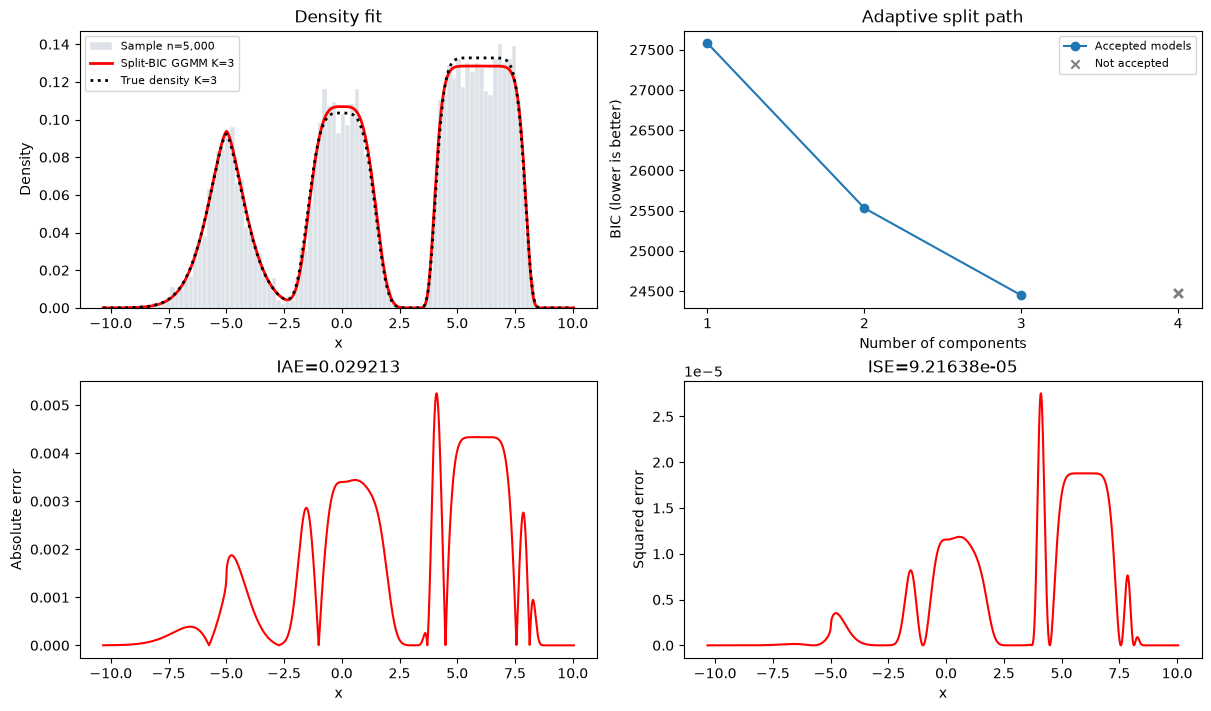

IAE·ISE는 그림 격자와 별도의 적응적 적분입니다. LL↑, BIC·IAE·ISE↓.
라이브러리 버전: {'python': '3.14.7', 'numpy': '2.5.3', 'scipy': '1.18.1', 'pandas': '3.0.5', 'matplotlib': '3.11.2'}


In [2]:
# 실험 1: 기존과 같은 표본에서 한 성분을 분할해 성장시키면 어디서 멈추는가?
# 이 셀은 같은 X를 새로 적합하고, 경로·파라미터·밀도·IAE·ISE·시간을 한 번에 보여줍니다.
# 참 K·파라미터는 생성과 사후 평가에만 사용합니다. result는 이번 새 적합입니다.
result = None
N = 5000
SEED = 20260912
truth = Mixture([.2,.3,.5],[-5.,0.,6.],[1.2,1.6,2.],[1.5,4.,8.])
X = sample_mixture(truth,N,SEED)
config = SplitBICConfig(safety_max_components=30)
print(f'관측 표본 n={N:,}, seed={SEED}')
display(pd.DataFrame([asdict(config)]))
result = run_split_experiment(X,truth,SEED,config)


새 적합 결과: {'n': 1000, 'config': {'safety_max_components': 30, 'scale_floor_relative': 0.001, 'max_iter': 1500, 'retry_multiplier': 2, 'ftol': 1e-10, 'gtol': 1e-05, 'bic_tolerance': 1e-06, 'min_split_mass': 8.0, 'split_methods': ('weighted_median', 'weighted_lloyd')}, 'selected_K': 1, 'selected_BIC': np.float64(3900.067045579466), 'selected_LL': np.float64(-1939.6718898712602), 'selected_converged': True, 'stop_reason': 'no_BIC_improving_split', 'searched_splits_at_stop_complete': True, 'at_safety_cap': False, 'optimizer_runs': 3, 'minimize_calls': 3, 'all_visited_rounds_fully_converged': True, 'skipped_parent_splits': 0, 'nonconverged_candidates': 0, 'failed_candidates': 0, 'total_iterations': 94, 'scale_floor_original_units': 0.0016949896440750297, 'fitted_K_not_thresholded': True, 'no_global_K_guarantee': True, 'seconds': 0.11300230002962053}
g(x;mu,a,b)=b/[2a Gamma(1/b)] exp(-|(x-mu)/a|^b)
추정 GGMM: 1 g(x; 1.01845, 2.03539, 1.55683)


,K,BIC,LL,IAE,ISE,Fit_s,Selected_fit_converged,Last_split_search_complete,Stop_reason
0,1,3900.067046,-1939.67189,0.014181,0.000031,0.113049,True,True,no_BIC_improving_split


,component,weight,mu,a,b,sigma_derived
0,1,1.0,1.018453,2.035393,1.556828,1.695625


,K,BIC,log_likelihood,split_parent,split_method,converged
0,1,3900.067046,-1939.67189,None,one_component,True


정지 시 검사한 다음 분할 후보 (delta_BIC가 음수여야 개선):


,K,split_parent,split_method,delta_LL,delta_BIC,converged,projected_gradient,stationarity_checked,accepted
0,2,1,weighted_median,3.953682,19.723657,True,0.000001,True,False
1,2,1,weighted_lloyd,3.953682,19.723658,True,0.000009,True,False


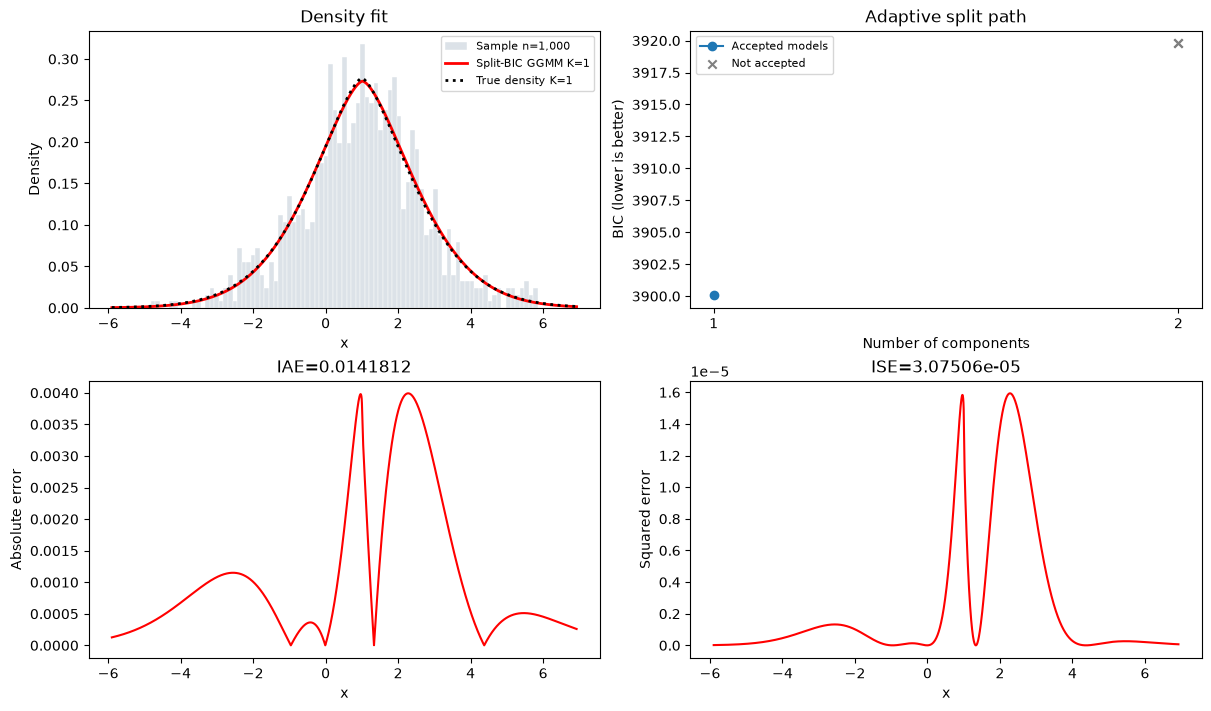

IAE·ISE는 그림 격자와 별도의 적응적 적분입니다. LL↑, BIC·IAE·ISE↓.
라이브러리 버전: {'python': '3.14.7', 'numpy': '2.5.3', 'scipy': '1.18.1', 'pandas': '3.0.5', 'matplotlib': '3.11.2'}
새 적합 결과: {'n': 5000, 'config': {'safety_max_components': 30, 'scale_floor_relative': 0.001, 'max_iter': 1500, 'retry_multiplier': 2, 'ftol': 1e-10, 'gtol': 1e-05, 'bic_tolerance': 1e-06, 'min_split_mass': 8.0, 'split_methods': ('weighted_median', 'weighted_lloyd')}, 'selected_K': 3, 'selected_BIC': np.float64(36532.786447239545), 'selected_LL': np.float64(-18219.548661066983), 'selected_converged': True, 'stop_reason': 'split_optimization_incomplete', 'searched_splits_at_stop_complete': False, 'at_safety_cap': False, 'optimizer_runs': 12, 'minimize_calls': 19, 'all_visited_rounds_fully_converged': False, 'skipped_parent_splits': 0, 'nonconverged_candidates': 7, 'failed_candidates': 0, 'total_iterations': 4761, 'scale_floor_original_units': 0.01001126581718127, 'fitted_K_not_thresholded': True, 'no_global_K_guarantee': True, 'se

,K,BIC,LL,IAE,ISE,Fit_s,Selected_fit_converged,Last_split_search_complete,Stop_reason
0,3,36532.786447,-18219.548661,0.573153,0.011673,24.136996,True,False,split_optimization_incomplete


,component,weight,mu,a,b,sigma_derived
0,1,0.331617,-8.207184,11.559093,37.921617,6.587291
1,2,0.431733,-0.329189,11.882012,2.492913,7.651980
2,3,0.236650,12.078734,7.379171,691.539186,4.256841


,K,BIC,log_likelihood,split_parent,split_method,converged
0,1,36767.743412,-18371.095916,NaN,one_component,True
1,2,36663.717484,-18302.048566,1.0,weighted_lloyd,True
2,3,36532.786447,-18219.548661,2.0,weighted_median,True


정지 시 검사한 다음 분할 후보 (delta_BIC가 음수여야 개선):


,K,split_parent,split_method,delta_LL,delta_BIC,converged,projected_gradient,stationarity_checked,accepted
0,4,1,weighted_median,110.402724,-186.736675,False,0.000299,False,False
1,4,2,weighted_median,87.187518,-140.306264,False,0.121239,False,False
2,4,2,weighted_lloyd,115.029942,-195.991112,False,0.091789,False,False
3,4,3,weighted_median,229.077047,-424.085322,False,3.390558,False,False
4,4,3,weighted_lloyd,173.143102,-312.217431,False,1750.366813,False,False


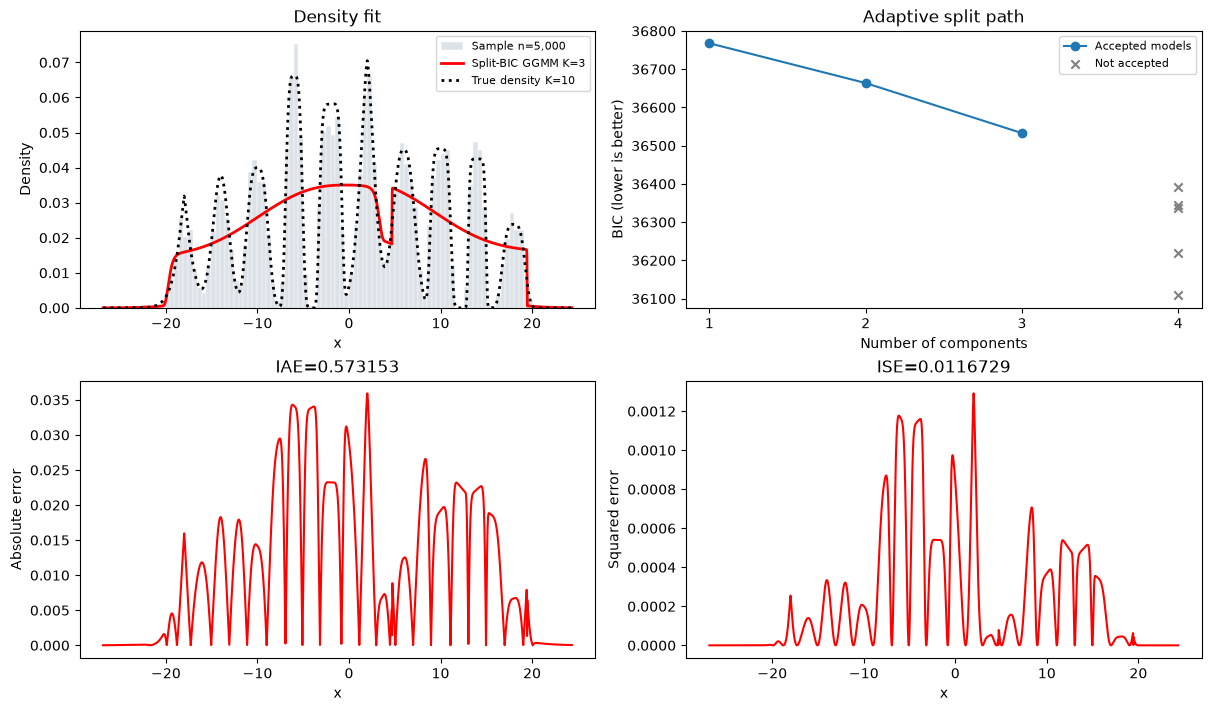

IAE·ISE는 그림 격자와 별도의 적응적 적분입니다. LL↑, BIC·IAE·ISE↓.
라이브러리 버전: {'python': '3.14.7', 'numpy': '2.5.3', 'scipy': '1.18.1', 'pandas': '3.0.5', 'matplotlib': '3.11.2'}


In [4]:
# 선택 실험 2: 한 개 분포에서 불필요한 분할을 하는가? 참 K=10에서는 성장할 수 있는가?
# 각각 같은 생성함수로 새 표본을 만들고 새로 적합합니다. 기본 result는 덮어쓰지 않습니다.
# 특히 미수렴으로 중단된 결과는 최종 성분 수 선택이 완성된 것으로 해석하지 않습니다.
RUN_EXTRA_CASES = True
if RUN_EXTRA_CASES:
    truth1 = Mixture([1.],[1.],[2.],[1.5])
    X1 = sample_mixture(truth1,1000,20261002)
    control_result = run_split_experiment(X1,truth1,20261002,config)
    truth10 = Mixture([.06,.08,.10,.12,.14,.14,.12,.10,.08,.06],
        [-18,-14,-10,-6,-2,2,6,10,14,18],
        [1.,1.2,1.4,1.,1.3,1.1,1.5,1.2,1.,1.4],
        [1.2,2.,3.,4.,6.,1.5,2.5,5.,8.,3.5])
    X10 = sample_mixture(truth10,5000,20260919)
    stress_result = run_split_experiment(X10,truth10,20260919,config)
else:
    print('미실행: 추가 사례는 RUN_EXTRA_CASES=True로 실행하세요.')
